# Building CLIP From Scratch

This notebook is contributed from:
* Medium Post: [Building CLIP From Scratch](https://medium.com/correll-lab/building-clip-from-scratch-68f6e42d35f4)
* [code](https://colab.research.google.com/drive/1E4sEg7RM8HBv4PkIhjWZuwCXXbB_MinS?usp=sharing#scrollTo=SHKmUq7V_qhH)

This notebook is to build CLIP model using **fashion MNIST** dataset from HuggingFace.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T

import numpy as np

from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ", device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")


/home/colligo/transformer/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device:  cuda (NVIDIA A100-SXM4-40GB)


## Fashion MNIST datasets

In [2]:
class FashionMNIST(Dataset):
    def __init__(self, train=True):
        self.dataset = load_dataset("fashion_mnist")

        self.transform = T.ToTensor()

        if train:
            self.split = "train"
        else:
            self.split = "test"


        self.captions = {0: "An image of a t-shirt/top",
                        1: "An image of trousers",
                        2: "An image of a pullover",
                        3: "An image of a dress",
                        4: "An image of a coat",
                        5: "An image of a sandal",
                        6: "An image of a shirt",
                        7: "An image of a sneaker",
                        8: "An image of a bag",
                        9: "An image of an ankle boot"}


    def __len__(self):
        return self.dataset.num_rows[self.split]

    def __getitem__(self,i):
        img = self.dataset[self.split][i]["image"]
        img = self.transform(img)

        cap, mask = tokenizer(self.captions[self.dataset[self.split][i]["label"]])

        mask = mask.repeat(len(mask), 1)

        return {"image": img, "caption": cap, "mask": mask}

## Attention and Multiattention

* **d_model** is the input dimension for Q, K, V
* **head_dim** is the output dimension of q, k, v after heads.

In [14]:
class Attention(nn.Module):
    def __init__(self, d_model, head_dim):
        super().__init__()
        
        self.d_model = d_model
        self.head_dim = head_dim

        self.W_q = nn.Linear(d_model, head_dim)
        self.W_k = nn.Linear(d_model, head_dim)
        self.W_v = nn.Linear(d_model, head_dim)
        
    def forward(self, x, mask=None):
        # Obtaining Queries, Keys, and Values
        
        q = self.W_q(x)
        k = self.W_k(x)
        v = self.W_v(x)
        
        # Dot Product of Queries and Keys
        attention = torch.matmul(q, k.transpose(-2,-1)) / (self.head_dim ** 0.5)

        # Applying Attention Mask
        if mask is not None:
            attention = attention.masked_fill(mask == 0, float("-inf"))

        attention = torch.softmax(attention, dim=-1)
        attention = torch.matmul(attention, v)
        return attention


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.head_dim = d_model // n_heads
        self.W_o = nn.Linear(d_model, d_model)
        self.multiheads = nn.ModuleList([Attention(d_model, self.head_dim) for _ in range(n_heads)])

    def forward(self, x, mask=None):
        # Combine attention heads
        out = torch.cat([head(x, mask=mask) for head in self.multiheads], dim=-1)
        out = self.W_o(out)
        return out

## Transformer Encoder 

This is generic transformer encoder, for both image/text encoder.

In [15]:
class TransformerEncoder(nn.Module):
    def __init__(self, d_model, n_heads, r_mlp=4):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads

        # Sub-Layer 1 Normalization
        self.layer_norm_1 = nn.LayerNorm(d_model)

        # Multi-Head Attention
        self.mha = MultiHeadAttention(d_model, n_heads)

        # Sub-Layer 2 Normalization
        self.layer_norm_2 = nn.LayerNorm(d_model)

        # Multilayer Perception
        self.mlp = nn.Sequential(
            nn.Linear(d_model, d_model * r_mlp),
            nn.GELU(),
            nn.Linear(d_model * r_mlp, d_model)
        )

    def forward(self, x, mask=None):
        # Residual Connection After Sub-Layer 1
        x = x + self.mha(self.layer_norm_1(x), mask=mask)
        # Residual Connection After Sub-Layer 2
        x = x + self.mlp(self.layer_norm_2(x))
        return x

## Text Tokensizer

In [5]:
def tokenizer(text, encode=True, mask=None, max_seq_length=32):
    if encode:
        out = chr(2) + text + chr(3) # Adding <SOT> at the begining and <EOT> in the end
        out = out + "".join([chr(0) for _ in range(max_seq_length-len(out))]) # Adding Padding
        out = torch.IntTensor(list(out.encode("utf-8"))) # Encoding Text
        mask = torch.ones(len(out.nonzero()))
        mask = torch.cat((mask,torch.zeros(max_seq_length-len(mask)))).type(torch.IntTensor)
    else:
        out = [chr(x) for x in text[1:len(mask.nonzero())-1]]
        out = "".join(out)
        mask = None

    return out, mask

## Text Encoder

For the text encoder, we are going to use a regular transformer model:

* Creating an embedding table of size (vocab_size, d_model). This embedding table contains a vector representation with a size equal to the d_model of the transformer model for each token in the vocabulary.
* The output of the encoder layers is the text features. We are going to be using the features from the EOT embedding.
* Finally, we embed the text features in the joint embedding space by getting the dot product between the features and the learned projection and normalize it by dividing by the normalized dot product.

In [19]:
class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super().__init__()
        pe = torch.zeros(max_seq_length, d_model)

        for pos in range(max_seq_length):
            for i in range(d_model):
                if i % 2 == 0:
                    pe[pos][i] = np.sin(pos/(10000 ** (i/d_model)))
                else:
                  pe[pos][i] = np.cos(pos/(10000 ** ((i-1)/d_model)))
    
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe
        return x

      
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_length, n_layers, n_heads, emb_dim):
        super().__init__()

        self.max_seq_length = max_seq_length
        self.encoder_embedding = nn.Embedding(vocab_size, d_model)

        self.positional_embedding = PositionalEmbedding(d_model, max_seq_length)
        self.encoder = nn.ModuleList([TransformerEncoder(d_model, n_heads) for _ in range(n_layers)])

        # learned proj of image to embed, initialize project layer here
        self.projection = nn.Parameter(torch.randn(d_model, emb_dim))

    def forward(self, token, mask=None):
        word_embedding = self.encoder_embedding(token)           # Text Embedding
        pos_encoded = self.positional_embedding(word_embedding)  # Positional Embedding
        
        for encoder_layer in self.encoder:                       # Transformer Encoder
            pos_encoded = encoder_layer(pos_encoded, mask=mask)

        # Takes features from the EOT Embedding
        x = pos_encoded[torch.arange(token.shape[0]), torch.sub(torch.sum(mask[:,0], dim=1), 1)]

        # joint multimodal embedding
        if self.projection is not None:
            x = x @ self.projection

        x = x / torch.norm(x, dim=-1, keepdim=True)
        return x

## Image Encoder

* Before inputing through the encoder layers, we first need to split the input image into patches and create a sequence of linear embeddings of these patches. We are able to achieve this by using PyTorch’s **Conv2d** method.
* **maximum sequence length** for the **positional encoding** will be equal to the **number of patches + 1**.
* The number of patches can be found by **(img_height** $\times$ **img_width)** / **(patch_height** $\times$ **patch_width)**.
* Vision transformers uses the standard approach of adding a **learnable classification token** to the patch embeddings in order to perform classification.
* We embed the image features in the joint embedding space by getting the **dot product between the features and the learned projection** and normalize it by dividing by the normalized dot product.

In [28]:
class ImageEncoder(nn.Module):
    def __init__(self, d_model, img_size, patch_size, n_channels, n_layers, n_heads, emb_dim):
        super().__init__()

        assert img_size[0] % patch_size[0] == 0 and img_size[1] % patch_size[1] == 0, "img_size dimensions must be divisible by patch_size dimensions"
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.n_patches = (img_size[0] * img_size[1]) // (patch_size[0] * patch_size[1])
        self.max_seq_length = self.n_patches + 1
        self.linear_project = nn.Conv2d(n_channels, d_model, kernel_size=patch_size, stride=patch_size)

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.positional_embedding = PositionalEmbedding(d_model, self.max_seq_length)

        self.encoder = nn.ModuleList([TransformerEncoder(d_model, n_heads) for _ in range(n_layers)])

        # learned proj of image to embed
        self.projection = nn.Parameter(torch.randn(d_model, emb_dim))

    def forward(self,x):
        # Patch Embedding
        x = self.linear_project(x) # (Batch, C, H, W) -> (B, d_model, P_col, P_row)
        x = x.flatten(2)           # (Batch, d_model, P_col, P_row) -> (B, d_model, P)
        x = x.transpose(1, 2)      # (Batch, d_model, P) -> (B, P, d_model)

        # Positional Embedding
        x = torch.cat((self.cls_token.expand(x.size()[0], -1, -1),x), dim=1)
        x = self.positional_embedding(x)

        # Transformer Encoder
        for encoder_layer in self.encoder:
            x = encoder_layer(x)

        # Getting Class Tokens
        x = x[:, 0, :]

        # joint multimodal embedding
        if self.projection is not None:
            x = x @ self.projection

        x = x / torch.norm(x, dim=-1, keepdim=True)

        return x

## CLIP

When given a batch of images and captions, CLIP is supposed to tell you which captions goes with which images. 

* It does this by training the text and image encoder together to **maximize the pairwise cosine similarity scores of the pairs** that are supposed to go together and minimizing the pairs that are not supposed to go together.
* CLIP uses symmetric/contrastive loss.

In [29]:
class CLIP(nn.Module):
    def __init__(self, emb_dim, vit_d_model, img_size, patch_size, n_channels, vit_layers, vit_heads, vocab_size, text_d_model, max_seq_length, text_heads, text_layers):
        super().__init__()

        self.image_encoder = ImageEncoder(vit_d_model, img_size, patch_size, n_channels, vit_layers, vit_heads, emb_dim)
        self.text_encoder = TextEncoder(vocab_size, text_d_model, max_seq_length, text_layers, text_heads, emb_dim)

        self.temperature = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def forward(self, image, text, mask=None):
        I_e = self.image_encoder(image)          # image-encoding
        T_e = self.text_encoder(text, mask=mask) # text-encoding

        # scaled pairwise cosine similarities [n, n]
        logits = (I_e @ T_e.transpose(-2,-1)) * torch.exp(self.temperature)

        # symmetric loss function
        labels = torch.arange(logits.shape[0]).to(self.device)

        loss_i = nn.functional.cross_entropy(logits.transpose(-2,-1), labels)
        loss_t = nn.functional.cross_entropy(logits, labels)

        loss = (loss_i + loss_t) / 2

        return loss

## Training Parameters

In [24]:
emb_dim = 32

n_channels = 1

img_size = (28, 28)
patch_size = (14, 14)

vit_layers = 3
vit_heads = 3
vit_d_model = 9

max_seq_length = 32

vocab_size = 256
text_layers = 4
text_heads = 8
text_d_model = 32


In [10]:
batch_size = 128

train_set = FashionMNIST(train = True)
test_set = FashionMNIST(train = False)

train_loader = DataLoader(
    train_set, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=8,           # Use 8 CPU cores to prepare data
    pin_memory=True,         # Fast-track data to the GPU
    prefetch_factor=2,       # Keep 2 batches ready in the queue
    persistent_workers=True  # Don't shut down workers between epochs
)

test_loader = DataLoader(
    test_set, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=8,           # Use 8 CPU cores to prepare data
    pin_memory=True,         # Fast-track data to the GPU
    prefetch_factor=2,       # Keep 2 batches ready in the queue
    persistent_workers=True  # Don't shut down workers between epochs
)

Generating test split: 100%|███| 10000/10000 [00:00<00:00, 407320.75 examples/s]


In [30]:

lr = 1e-3
epochs = 10

model = CLIP(emb_dim, vit_d_model, img_size, patch_size, n_channels, vit_layers, vit_heads, vocab_size, text_d_model, max_seq_length, text_heads, text_layers).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

best_loss = np.inf
for epoch in range(epochs):
    for i, data in enumerate(train_loader, 0):
        img, cap, mask = data["image"].to(device), data["caption"].to(device), data["mask"].to(device)
        loss = model(img, cap, mask)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}], Batch Loss: {loss.item():.3f}")

    # Saves model if it performed better than the previous best
    if loss.item() <= best_loss:
        best_loss = loss.item()
        # if epoch % 20 == 0:
        #     torch.save(model.state_dict(), "./clip.pt")
        #     print(f"Model Saved on {epoch}.")

Epoch [1/10], Batch Loss: 2.878
Model Saved on 0.
Epoch [2/10], Batch Loss: 2.978
Epoch [3/10], Batch Loss: 2.712
Epoch [4/10], Batch Loss: 2.742
Epoch [5/10], Batch Loss: 2.806
Epoch [6/10], Batch Loss: 2.772
Epoch [7/10], Batch Loss: 2.761
Epoch [8/10], Batch Loss: 2.723
Epoch [9/10], Batch Loss: 2.668
Epoch [10/10], Batch Loss: 2.722


## Testing

In [33]:

# Getting dataset captions to compare images to
text = torch.stack([tokenizer(x)[0] for x in test_set.captions.values()]).to(device)
mask = torch.stack([tokenizer(x)[1] for x in test_set.captions.values()])
mask = mask.repeat(1,len(mask[0])).reshape(len(mask),len(mask[0]),len(mask[0])).to(device)

correct, total = 0,0
with torch.no_grad():
    for data in test_loader:
        images, labels = data["image"].to(device), data["caption"].to(device)
        image_features = model.image_encoder(images)
        text_features = model.text_encoder(text, mask=mask)

        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        _, indices = torch.max(similarity,1)
        pred = torch.stack([tokenizer(test_set.captions[int(i)])[0] for i in indices]).to(device)
        correct += int(sum(torch.sum((pred==labels),dim=1)//len(pred[0])))
        total += len(labels)

print(f'\nModel Accuracy: {100 * correct // total} %')


Model Accuracy: 83 %


## Zero-Shot Classification

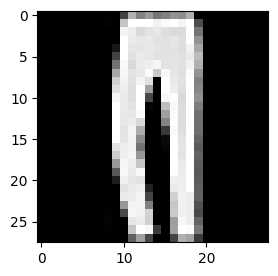

        trousers: 100.00%
         sneaker: 0.00%
            coat: 0.00%
           dress: 0.00%
      ankle boot: 0.00%
------------------------------------------------


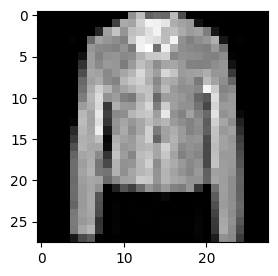

            coat: 100.00%
        pullover: 0.00%
           shirt: 0.00%
      ankle boot: 0.00%
     t-shirt/top: 0.00%
------------------------------------------------


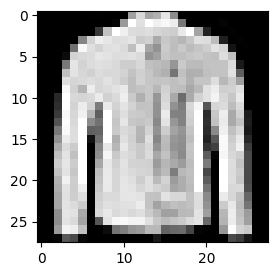

            coat: 100.00%
           shirt: 0.00%
        pullover: 0.00%
     t-shirt/top: 0.00%
      ankle boot: 0.00%
------------------------------------------------


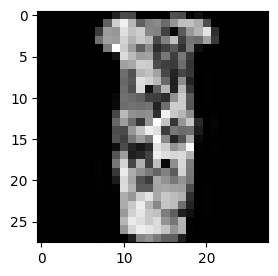

           dress: 100.00%
            coat: 0.00%
     t-shirt/top: 0.00%
        trousers: 0.00%
           shirt: 0.00%
------------------------------------------------


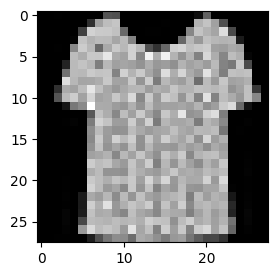

           shirt: 99.98%
     t-shirt/top: 0.02%
        pullover: 0.00%
           dress: 0.00%
            coat: 0.00%
------------------------------------------------


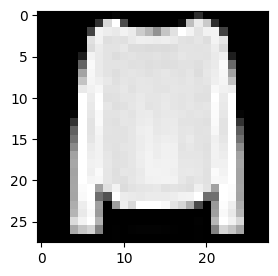

        pullover: 99.90%
            coat: 0.07%
           shirt: 0.03%
     t-shirt/top: 0.00%
             bag: 0.00%
------------------------------------------------


In [32]:

import matplotlib.pyplot as plt

# Captions to compare images to
class_names =["t-shirt/top",
                        "trousers",
                        "pullover",
                        "dress",
                        "coat",
                        "sandal",
                        "shirt",
                        "sneaker",
                        "bag",
                        "ankle boot"]

text = torch.stack([tokenizer(x)[0] for x in class_names]).to(device)
mask = torch.stack([tokenizer(x)[1] for x in class_names])
mask = mask.repeat(1,len(mask[0])).reshape(len(mask),len(mask[0]),len(mask[0])).to(device)

idx = 1000

for idx in [2, 10, 50, 100, 1000, 2500]:
    img = test_set[idx]["image"][None,:]

    plt.figure(figsize=(6, 3))
    plt.imshow(img[0].permute(1, 2, 0)  ,cmap="gray")
    # plt.title(tokenizer(test_set[idx]["caption"], encode=False, mask=test_set[idx]["mask"][0])[0])
    plt.show()
    img = img.to(device)
    with torch.no_grad():
      image_features = model.image_encoder(img)
      text_features = model.text_encoder(text, mask=mask)
    
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(5)
    
    # Print the result
    # print("\nTop predictions:\n")
    for value, index in zip(values, indices):
        print(f"{class_names[int(index)]:>16s}: {100 * value.item():.2f}%")

    print('------------------------------------------------')


In [35]:
len(test_set)

10000